## Churn Prediction Model using Random Forest

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os, sys

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)
from preprocessing import data_preprocessing
from plots_model import churn_prediction

In [2]:
path = root_dir + "/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

data = data_preprocessing(path)

data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,0,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,1,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


## Define features and target

In [3]:
features = list(data.columns[data.columns!="Churn"])
target = ["Churn"]

X = data[features]
y = data[target].values.ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

## Here we build and tune tree based random forest model

## Hyperparamter tuning

Here we do hyperparameter tuning step by step. 

### Grid 1

First we concentrate on find the best hyper parameter for 'max_features' and 'n_estimators'

In [4]:
param_grid1 = {'max_features':['auto', 'sqrt', 'log2', None],
          'n_estimators':[300, 500, 700, 900, 1100, 1300]
         }

rf_model = RandomForestClassifier()
grid1 = GridSearchCV(estimator=rf_model, param_grid=param_grid1, n_jobs=-1, cv=3, verbose=1, scoring = 'f1')
grid1.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_features': ['auto', 'sqrt', 'log2', None],
                         'n_estimators': [300, 500, 700, 900, 1100, 1300]},
             scoring='f1', verbose=1)

In [5]:
grid1.best_estimator_

RandomForestClassifier(n_estimators=700)

<Axes: xlabel='param_max_features', ylabel='param_n_estimators'>

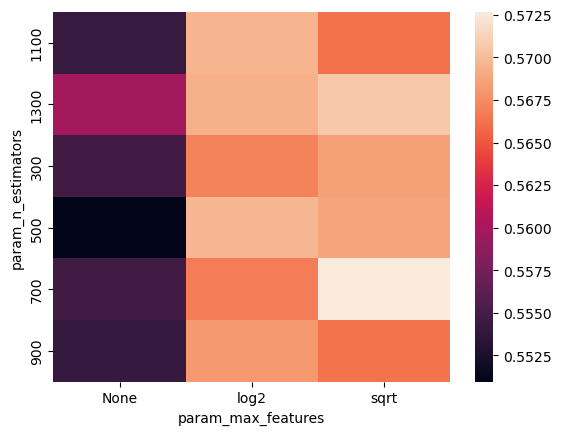

In [6]:
dt = pd.DataFrame(grid1.cv_results_)
dt.param_max_features = dt.param_max_features.astype(str)
dt.param_n_estimators = dt.param_n_estimators.astype(str)

table = pd.pivot_table(dt, 
                       index='param_n_estimators', 
                       columns='param_max_features',
                       values='mean_test_score', 
                       )
     
sns.heatmap(table)

In [7]:
grid1.best_score_

0.5726637767708164

### Grid 2

We use the best paramter from the previous grid for further tuning.

Now, let's move on to do hyper parameter tuning on 'criterion' and 'max_depth'

In [8]:
param_grid2 = {'max_features':['log2'],
          'n_estimators':[1000, 1100, 1200],
           'criterion': ['entropy', 'gini'],    
          'max_depth': [7, 9, 11, 13, 15, None],
         }

rf_model = RandomForestClassifier()
grid2 = GridSearchCV(estimator=rf_model, param_grid=param_grid2, n_jobs=-1, cv=3, verbose=1, scoring = 'f1')
grid2.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [7, 9, 11, 13, 15, None],
                         'max_features': ['log2'],
                         'n_estimators': [1000, 1100, 1200]},
             scoring='f1', verbose=1)

In [9]:
grid2.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=13, max_features='log2',
                       n_estimators=1000)

<Axes: xlabel='param_criterion', ylabel='param_max_depth'>

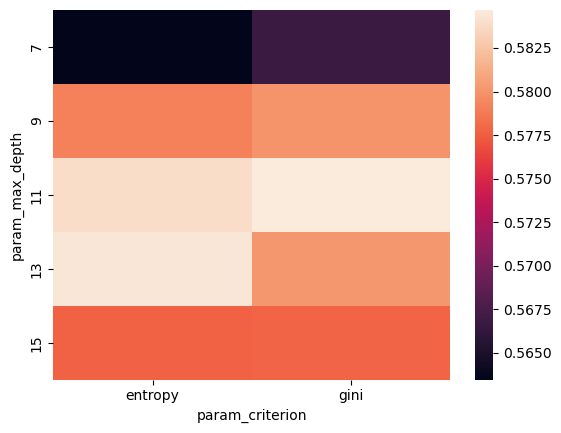

In [10]:
dt = pd.DataFrame(grid2.cv_results_)

table = pd.pivot_table(dt, 
                       index='param_max_depth', 
                       columns='param_criterion',
                       values='mean_test_score', 
                       )
     
sns.heatmap(table)

<Axes: xlabel='param_n_estimators', ylabel='param_max_depth'>

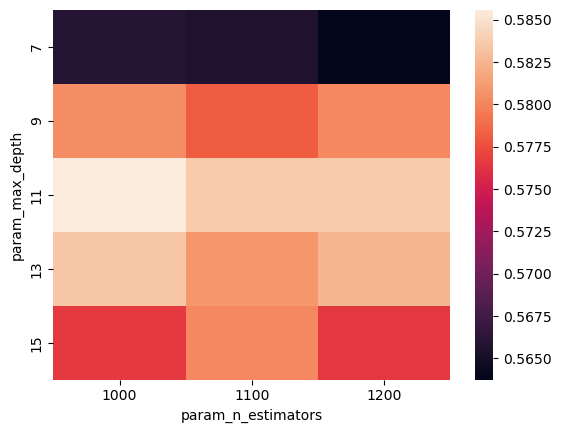

In [11]:
table = pd.pivot_table(dt, 
                       index='param_max_depth', 
                       columns='param_n_estimators',
                       values='mean_test_score', 
                       )
     
sns.heatmap(table)


In [12]:
grid2.best_score_

0.5869044511318374

In [13]:
param_grid2_2 = {'max_features':['log2'],
          'n_estimators':[950, 1000, 1050],
           'criterion': ['entropy'],    
          'max_depth': [10, 11, 12],
         }

rf_model = RandomForestClassifier()
grid2_2 = GridSearchCV(estimator=rf_model, 
                       param_grid=param_grid2_2, 
                       n_jobs=-1, 
                       cv=3, 
                       verbose=1, 
                       scoring = 'f1')
grid2_2.fit(X_train, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ['entropy'], 'max_depth': [10, 11, 12],
                         'max_features': ['log2'],
                         'n_estimators': [950, 1000, 1050]},
             scoring='f1', verbose=1)

In [14]:
grid2_2.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=12, max_features='log2',
                       n_estimators=950)

In [15]:
grid2_2.best_score_

0.5867244604245793

### Grid 3

Now let's tune 'min_samples_leaf' and 'min_samples_split'


In [16]:
param_grid3 = {'max_features':['log2'],
          'n_estimators':[1000],
           'criterion': ['entropy'],    
          'max_depth': [10],
          'min_samples_leaf': [1, 3, 5, 7],
          'min_samples_split': [2, 4, 6, 8]
         }

rf_model = RandomForestClassifier()
grid3 = GridSearchCV(estimator=rf_model, 
                     param_grid=param_grid3, 
                     n_jobs=-1, 
                     cv=3, 
                     verbose=1, 
                     scoring = 'f1')
grid3.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ['entropy'], 'max_depth': [10],
                         'max_features': ['log2'],
                         'min_samples_leaf': [1, 3, 5, 7],
                         'min_samples_split': [2, 4, 6, 8],
                         'n_estimators': [1000]},
             scoring='f1', verbose=1)

In [17]:
grid3.best_estimator_.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 'log2',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 1000,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

<Axes: xlabel='param_min_samples_split', ylabel='param_min_samples_leaf'>

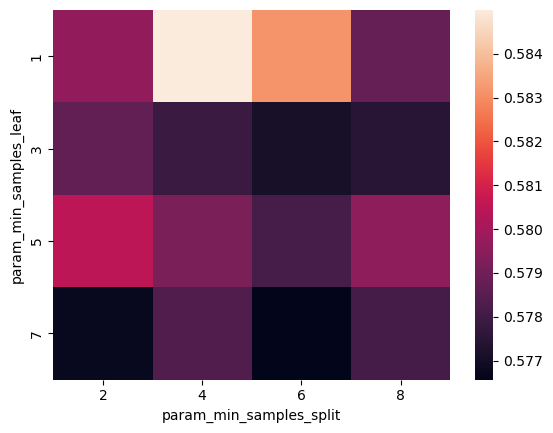

In [18]:
dt = pd.DataFrame(grid3.cv_results_)

table = pd.pivot_table(dt, values='mean_test_score', index='param_min_samples_leaf', 
                       columns='param_min_samples_split')
     
sns.heatmap(table)

In [19]:
grid3.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=10, max_features='log2',
                       min_samples_split=4, n_estimators=1000)

In [20]:
grid3.best_score_

0.5849980676788357

## Grid 4

Now, we tune class weight

In [21]:
param_grid4 = {'class_weight':[{0:1, 1:1}, {0:1, 1:2}, {0:1, 1:3}],
            'max_features':['log2'],
          'n_estimators':[1000],
           'criterion': ['entropy'],    
          'max_depth': [10],
          'min_samples_leaf': [3],
          'min_samples_split': [4]
         }

rf_model = RandomForestClassifier()
grid4 = GridSearchCV(estimator=rf_model, param_grid=param_grid4, n_jobs=-1, cv=3, verbose=1, scoring = 'f1')
grid4.fit(X_train, y_train)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 2},
                                          {0: 1, 1: 3}],
                         'criterion': ['entropy'], 'max_depth': [10],
                         'max_features': ['log2'], 'min_samples_leaf': [3],
                         'min_samples_split': [4], 'n_estimators': [1000]},
             scoring='f1', verbose=1)

In [22]:
grid4.best_estimator_

RandomForestClassifier(class_weight={0: 1, 1: 3}, criterion='entropy',
                       max_depth=10, max_features='log2', min_samples_leaf=3,
                       min_samples_split=4, n_estimators=1000)

<Axes: ylabel='param_class_weight'>

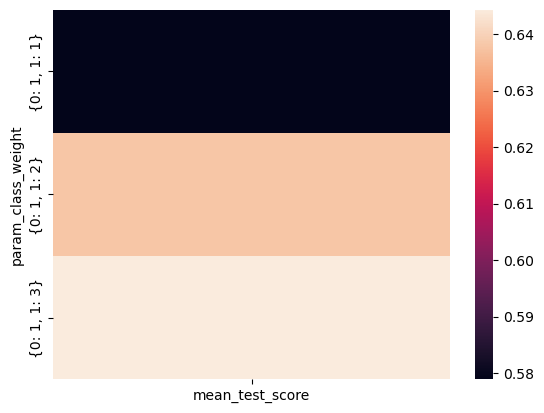

In [23]:
dt = pd.DataFrame(grid4.cv_results_)
dt.param_class_weight = dt.param_class_weight.astype(str)
table = pd.pivot_table(dt, 
                       index='param_class_weight',
                       values='mean_test_score', )
     
sns.heatmap(table)

In [24]:
grid4.best_score_

0.6443293585367508

In [25]:
grid4.best_estimator_.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': {0: 1, 1: 3},
 'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 'log2',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 3,
 'min_samples_split': 4,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 1000,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

## Final Model

In [4]:
params = {'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': {0: 1, 1: 3},
 'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 'log2',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 3,
 'min_samples_split': 4,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 1000,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

model = RandomForestClassifier(**params)

RandomForestClassifier(class_weight={0: 1, 1: 3}, criterion='entropy',
                       max_depth=10, max_features='log2', min_samples_leaf=3,
                       min_samples_split=4, n_estimators=1000)

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.79      0.84      1021
           1       0.57      0.75      0.65       388

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.80      0.78      0.78      1409

Accuracy Score: 0.7764371894960965
Area under curve :  0.8501241960075527 



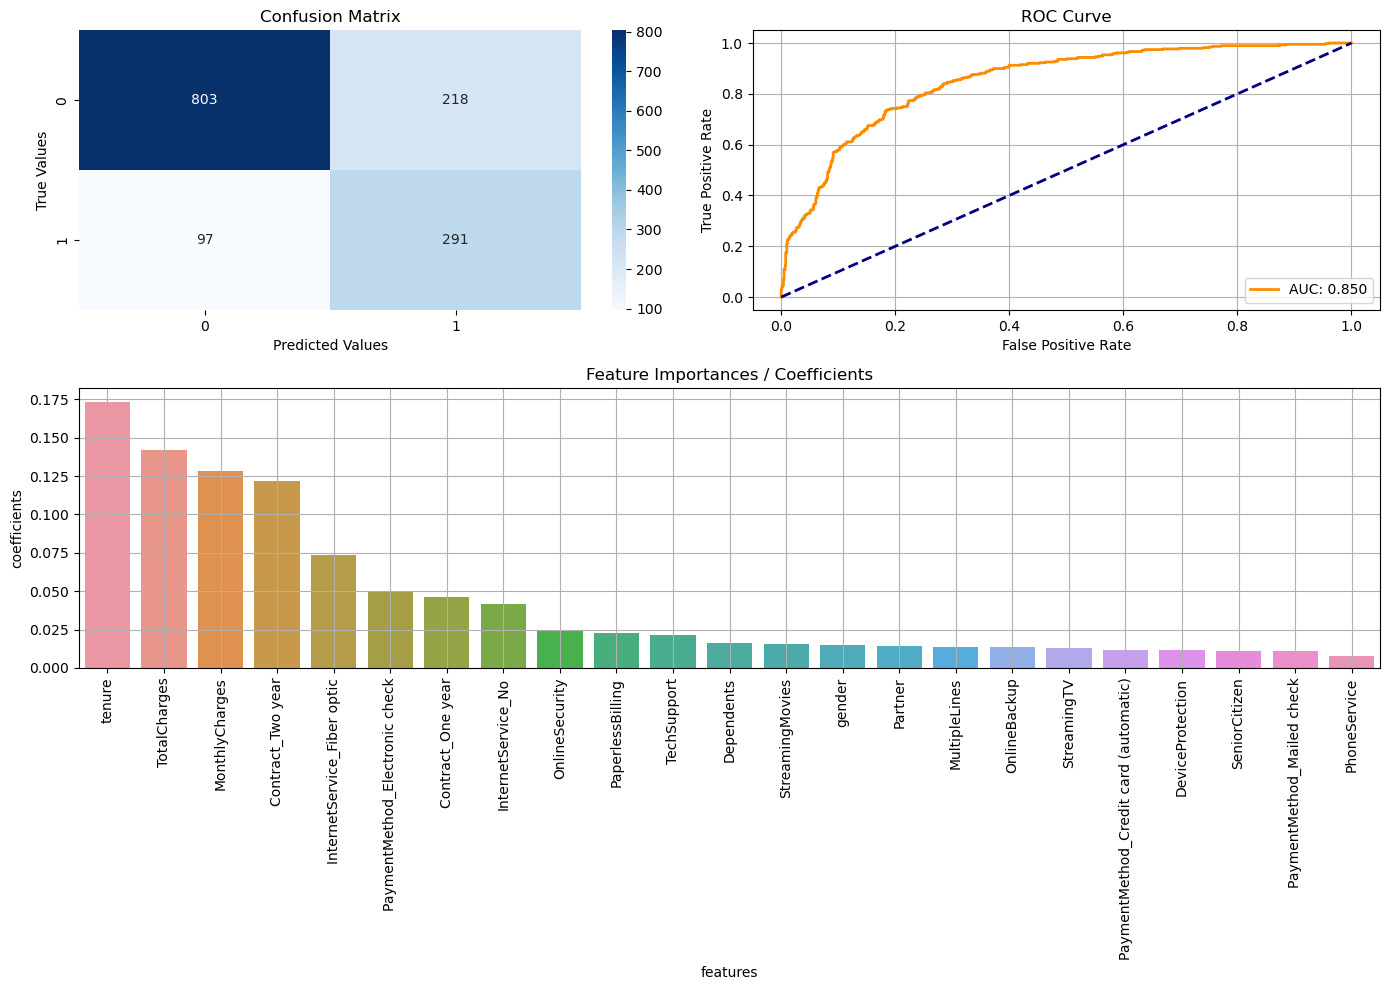

In [5]:
churn_prediction(model, X_train, y_train, X_test, y_test, features, "features")


In [6]:
train_scores = cross_val_score(model, X_train, y_train, cv = 5, scoring='f1')

print("The scores on cross validation sets are: \n",train_scores)

print("\n The mean of the scores is: \n", np.mean(train_scores))

The scores on cross validation sets are: 
 [0.65260197 0.63262411 0.6318927  0.61951909 0.6091954 ]

 The mean of the scores is: 
 0.6291666554129561


In [7]:
y_pred = model.predict(X_test)

f1 = f1_score(y_test, y_pred)
print("The score on test data is:", f1)

The score on test data is: 0.6488294314381272


- The mean F1 score from 5-fold cross-validation on the training data is approximately 0.65.
- Since this is comparable to the F1 score on the test set, it suggests that the model is not overfitting or underfitting significantly, although there may still be room for improvement.

## Saving the model

In [36]:
import pickle
pickle.dump(model, open('model.pkl','wb'))


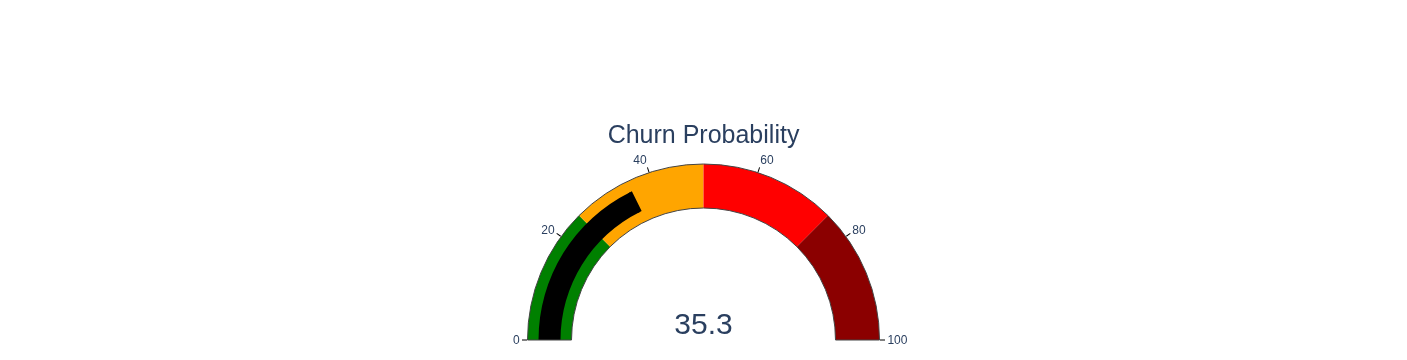

In [132]:
import plotly.graph_objects as go

# Example value (say churn probability)

def gauge(probability=1, fname=False): 
    
    fig = go.Figure(go.Indicator(
        mode = "gauge+number",
        value = probability * 100,  # scale to %
        number = {'font': {'size': 30}},
        title = {'text': "Churn Probability", 'font': {'size': 25}},
        gauge = {
            'axis': {
                'range': [0, 100], 
                'tickwidth': 1, 
                'tickcolor': "black"
            },
            'bar': {'color': "black"},  # pointer color
            'steps': [
                {'range': [0, 25], 'color': "green"},
                {'range': [25, 50], 'color': "orange"},
                {'range': [50, 75], 'color': "red"},
                {'range': [75, 100], 'color': "darkred"}
            ],
            'threshold': {
                'line': {'color': "black", 'width': 4},
                'thickness': 0.5,
                'value': probability * 100
            }
        },
        domain={'x': [0, 1], 'y': [0, 0.55]}  # restrict gauge to bottom half → 180°
    ))

    fig.update_layout(
        margin={'t':20, 'b':20, 'l':0, 'r':0},
        height=300,
        width=400
    )
    
    if fname:
        fig.write_image(fname)
        
    fig.show()

gauge(probability= model.predict_proba(X_test.iloc[0:1])[0,1], fname = root_dir+ "/churn_gauge.png")